In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

from backbone import compute_backbone
from backbone.plotting import plot_network

In [2]:
df = pd.read_csv("Adj_df.csv", index_col=0)

M = df.values
node_labels = df.columns.values.tolist()

non orphan ratio

	Optimal alpha  : 0.028290
	Modularity Q   : 0.8914
	non orphan ratio : 0.9873
	Combined score : 0.8801
	# communities  : 16
	Backbone nodes : 79
	Backbone edges : 141

giant component ratio

	Optimal alpha  : 0.251564
	Modularity Q   : 0.6536
	giant component ratio : 0.9241
	Combined score : 0.6040
	# communities  : 6
	Backbone nodes : 79
	Backbone edges : 577



/home/fciulla/coding/miscellanea/networksML/jul2026/backbone/__init__.py:187: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


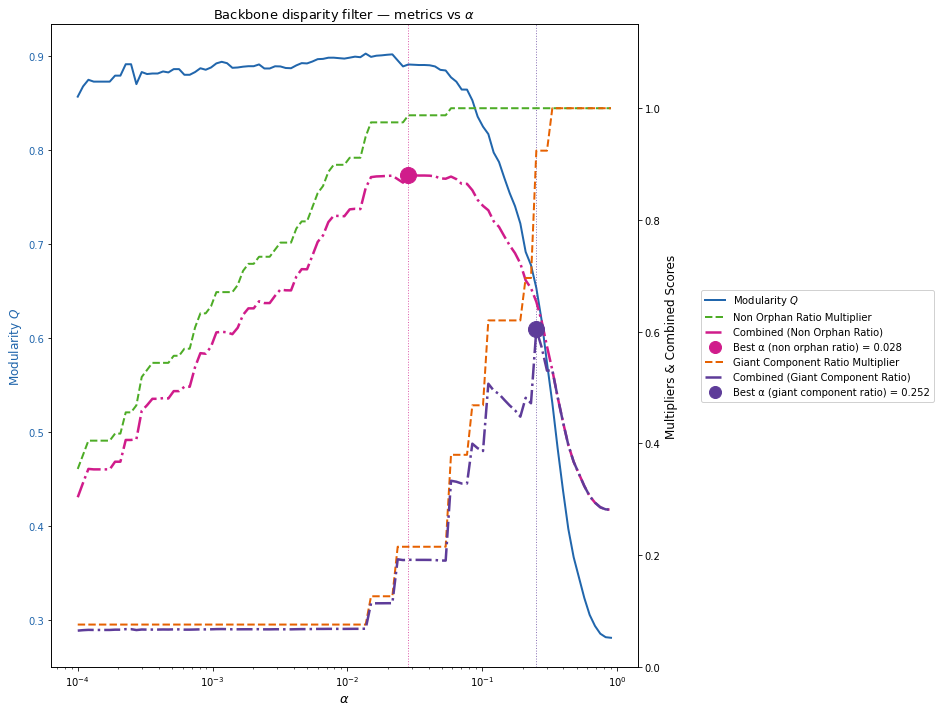

In [3]:
rationales = ["non orphan ratio", "giant component ratio"]

result = compute_backbone(
    M,
    #alpha=None,         # automatic golden-section search
    alpha = np.logspace(-4, np.log10(0.9), 101),
    method="louvain",
    tol=1e-3,
    plot=True,
    save_plot="backbone_metrics.png",
    rationales=rationales
)

# ── Results ───────────────────────────────────────────────────────────────────
for rationale in result.keys():
    print(rationale)
    print(f"\n\tOptimal alpha  : {result[rationale].alpha:.6f}")
    print(f"\tModularity Q   : {result[rationale].score:.4f}")
    print(f"\t{result[rationale].rationale} : {result[rationale].multiplier_value:.4f}")
    print(f"\tCombined score : {result[rationale].combined_score:.4f}")
    print(f"\t# communities  : {len(set(result[rationale].communities.values()))}")
    print(f"\tBackbone nodes : {result[rationale].backbone.number_of_nodes()}")
    print(f"\tBackbone edges : {result[rationale].backbone.number_of_edges()}")
    print()

/tmp/ipykernel_1385453/131480677.py:10: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


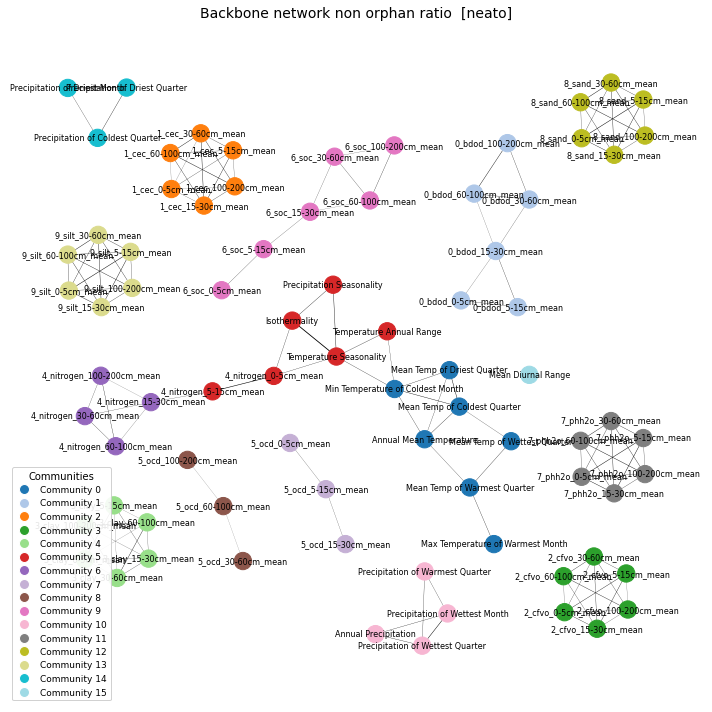

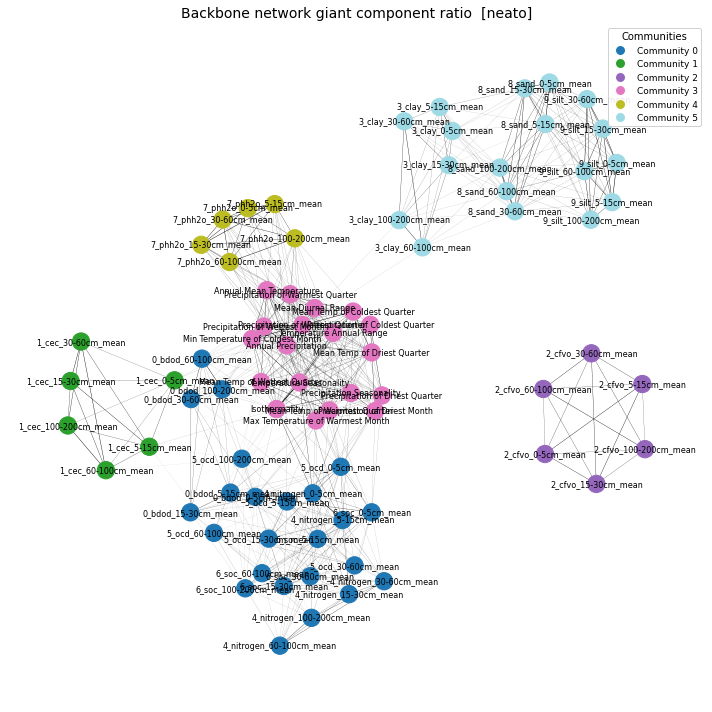

In [4]:
for rationale in rationales:
    fig = plot_network(
    result[rationale].backbone,
    communities=result[rationale].communities,
    labels=node_labels,
    title="Backbone network %s" % rationale,
    save_path="backbone_network_%s.png" % rationale,
    layout='neato'
    )
    fig.show()